$$\Large \text{Física Computacional  24/25}$$

 $\Huge\text{Tema 3: Interpolación y extrapolación}$

<h1>Índice del tema 3<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#3.1-Tipos-de-interpolación" data-toc-modified-id="3.1-Tipos-de-interpolación-1">3.1 Tipos de interpolación</a></span></li><li><span><a href="#3.2-Interpolación-polinómica" data-toc-modified-id="3.2-Interpolación-polinómica-2">3.2 Interpolación polinómica</a></span><ul class="toc-item"><li><span><a href="#3.2.1-Interpolando-dos-puntos" data-toc-modified-id="3.2.1-Interpolando-dos-puntos-2.1">3.2.1 Interpolando dos puntos</a></span><ul class="toc-item"><li><span><a href="#Error-en-la-interpolación-lineal" data-toc-modified-id="Error-en-la-interpolación-lineal-2.1.1">Error en la interpolación lineal</a></span></li></ul></li><li><span><a href="#3.2.2:-Interpolación-polinómica-de-grado-arbitrario" data-toc-modified-id="3.2.2:-Interpolación-polinómica-de-grado-arbitrario-2.2">3.2.2: Interpolación polinómica de grado arbitrario</a></span><ul class="toc-item"><li><span><a href="#Ejercicio-3.1:-demostración-de-la-interpolación-de-Lagrange" data-toc-modified-id="Ejercicio-3.1:-demostración-de-la-interpolación-de-Lagrange-2.2.1">Ejercicio 3.1: demostración de la interpolación de Lagrange</a></span></li><li><span><a href="#Implementación-numérica-de-la-interpolación-polinómica" data-toc-modified-id="Implementación-numérica-de-la-interpolación-polinómica-2.2.2">Implementación numérica de la interpolación polinómica</a></span></li><li><span><a href="#El-fenómeno-de-Runge" data-toc-modified-id="El-fenómeno-de-Runge-2.2.3">El fenómeno de Runge</a></span></li><li><span><a href="#Ejemplo-3.1:-la-función-de-Runge" data-toc-modified-id="Ejemplo-3.1:-la-función-de-Runge-2.2.4">Ejemplo 3.1: la función de Runge</a></span></li></ul></li></ul></li><li><span><a href="#3.3-Interpolación-a-trozos:-splines" data-toc-modified-id="3.3-Interpolación-a-trozos:-splines-3">3.3 Interpolación a trozos: splines</a></span><ul class="toc-item"><li><span><a href="#3.3.1-Algoritmo-para-determinar-los-coeficientes-de-un-spline-cúbico" data-toc-modified-id="3.3.1-Algoritmo-para-determinar-los-coeficientes-de-un-spline-cúbico-3.1">3.3.1 Algoritmo para determinar los coeficientes de un spline cúbico</a></span><ul class="toc-item"><li><span><a href="#Ejemplo-3.2:-interpolación-por-splines-de-la-función-de-Runge" data-toc-modified-id="Ejemplo-3.2:-interpolación-por-splines-de-la-función-de-Runge-3.1.1">Ejemplo 3.2: interpolación por splines de la función de Runge</a></span></li></ul></li><li><span><a href="#Ejercicio-3.2:-la-interacción-protón---neutrón" data-toc-modified-id="Ejercicio-3.2:-la-interacción-protón---neutrón-3.2">Ejercicio 3.2: la interacción protón - neutrón</a></span></li></ul></li><li><span><a href="#3.4:--Aproximaciones-racionales:-aproximantes-de-Padé" data-toc-modified-id="3.4:--Aproximaciones-racionales:-aproximantes-de-Padé-4">3.4:  Aproximaciones racionales: aproximantes de Padé</a></span><ul class="toc-item"><li><span><a href="#Ejemplo-3.3:-interpolando-singularidades" data-toc-modified-id="Ejemplo-3.3:-interpolando-singularidades-4.1">Ejemplo 3.3: interpolando singularidades</a></span></li><li><span><a href="#Ejercicio-3.3:-aproximantes-P[N/1]" data-toc-modified-id="Ejercicio-3.3:-aproximantes-P[N/1]-4.2">Ejercicio 3.3: aproximantes P[N/1]</a></span></li><li><span><a href="#Ejercicio-3.4:-aproximantes-de-Padé-y-resonancias." data-toc-modified-id="Ejercicio-3.4:-aproximantes-de-Padé-y-resonancias.-4.3">Ejercicio 3.4: aproximantes de Padé y resonancias.</a></span></li></ul></li></ul></div>

# 3.1 Tipos de interpolación

- Generalmente los experimentos sólo proporcionan un conjunto discreto de datos $(x_i,f_i)$ que representan el valor de una función para un conjunto finito de argumentos $\{x_0,\cdots,x_n\}$.
 
 
- Si puntos adicionales son necesarios, por ejemplo para representar la función o usarla como argumento de otra, por ejemplo en una integral, necesitamos interpolar ese conjunto discreto de datos.


- La interpolación es por tanto necesaria para representar una función complicada por una más simple o para poder integrarla o derivarla. 


- De forma general, dada una muestra de $N+1$ puntos $(x_i ,\;f_i )$ con $i = 0,\cdots N$ y una función de $x$ que depende de $M+1$ parámetros $c_i$

    $$\Phi(x;c_0,\cdots,c_M),$$

    el problema consiste en encontrar el valor de los coeficientes $c_i$ que satisfacen:

    $$\Phi(x_i;c_0,\cdots,c_M)=f_i,\quad\text{con}\quad i=0,\cdots,N,$$
    
    es decir, que imponen que nuestra función coincide con los $N+1$ datos.

In [ ]:
# Si tengo N puntos, desarrollo f(x) en Taylor y resuelvo el sistema de ecuaciones inhomogéneo con condiciones
# p(x_i)=f(x_i) // Que pase por todos los puntos empleados.

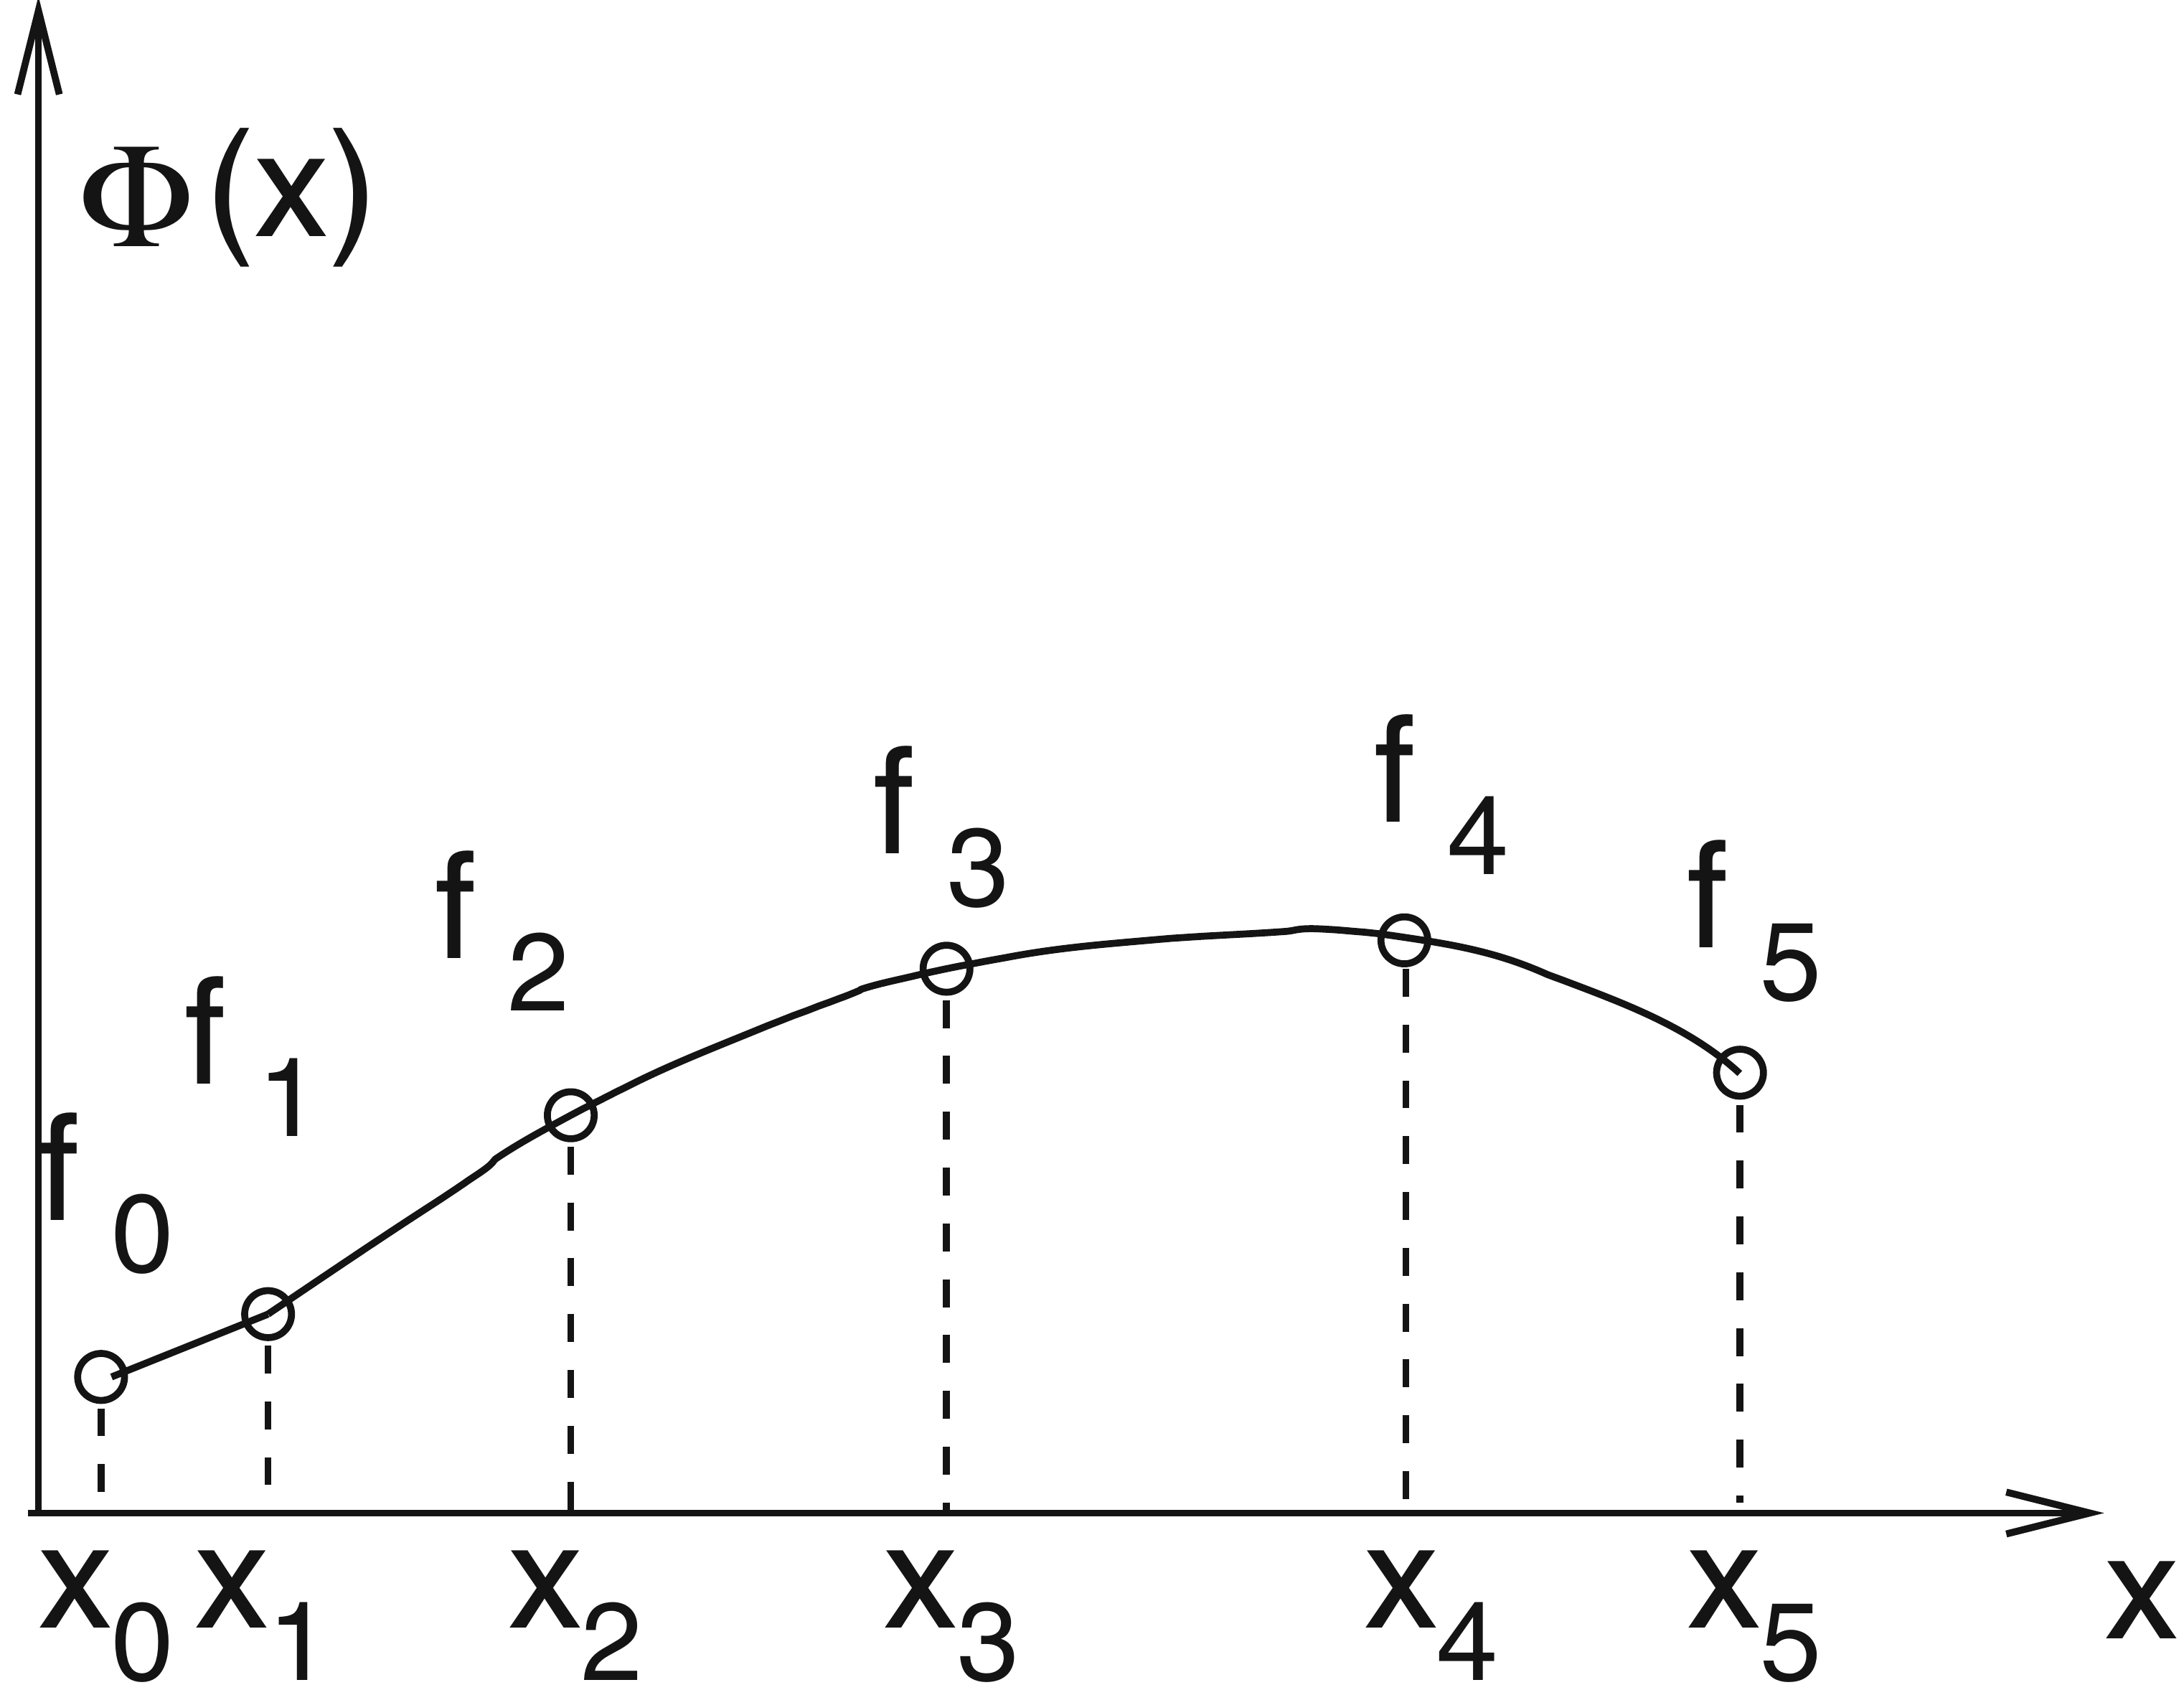

In [5]:
from IPython.display import display,Image
display(Image(filename="int_ex.png",width=600,height=600))

- Si $M>N$, nuestra función (forma funcional) tiene demasiados parámetros.


- Si $M<N$, en general no hay solución al problema, por lo que uno tiene que aproximar en vez de interpolar.   
  En general se suele hacer por medio del método de los mínimos cuadrados, o del $\chi^2$.   
  Son los problemas de minimización/optimización que estudiaremos en el Tema 5. 
  

- Si $M=N$, el problema tiene solución única. Es el llamado problema de interpolación que vamos a estudiar en este tema.


- Principalmente, estudiaremos la interpolación lineal, donde la función $\Phi(x)$ cumple:

    $$\Phi(x)=\sum_{i=0}^N{c_i\,\Phi_i(x)},$$

    una excepción son los interpoladores de Padé, que vienen dados por funciones racionales (el cociente de dos funciones lineales). 
    

- En particular nos centraremos en la interpolación por medio de:
   <br>
   
    1. polinomios, 

        $$\Phi(x)=\sum_{i=0}^N{c_i\,x^i},$$
    <br>
    
    2. splines cúbicos
 
     $$\Phi(x)=\sum_{i=0}^{N-1}{s_i(x)}\,\Theta(x-x_i)\,\Theta(x_{i+1}-x),\quad\text{con}\quad s_i(x)=\sum_{j=0}^3{c_{ij}(x-x_i)^j}$$
     <br>
     
    3. aproximaciones racionales: aproximantes de Padé 

    $$\Phi(x)=\frac{\displaystyle\sum_{i=0}^{n_1}{c_i\,x^i}}{\displaystyle\sum_{i=0}^{n_2}{d_i\,x^i}},\quad\text{con}\quad n_1+n_2=N-1$$
   
    4. interpolación trigonométrica o análisis de Fourier, 

    $$\Phi(x)=\sum_{n=0}^N{c_i\,e^{\,i\,n\,x}},$$

  $\quad$ que será estudiado en el Tema 6. 

# 3.2 Interpolación polinómica

## 3.2.1 Interpolando dos puntos

- Asumamos que conocemos la función $f(x)$ en sólo dos puntos $a$ y $b$ y que necesitamos evaluarla en un punto entre medias. 


- Hay infinitas formas de hacerlo, pero la más sencilla es asumir que la curva que las conecta es una línea recta.

    $$f(x)\simeq p_l(x)=f(a)+\frac{f(b)-f(a)}{b-a}(x-a)=\frac{(b-x)\,f(a)+(x-a)\,f(b)}{b-a},$$

  es la interpolación lineal. 

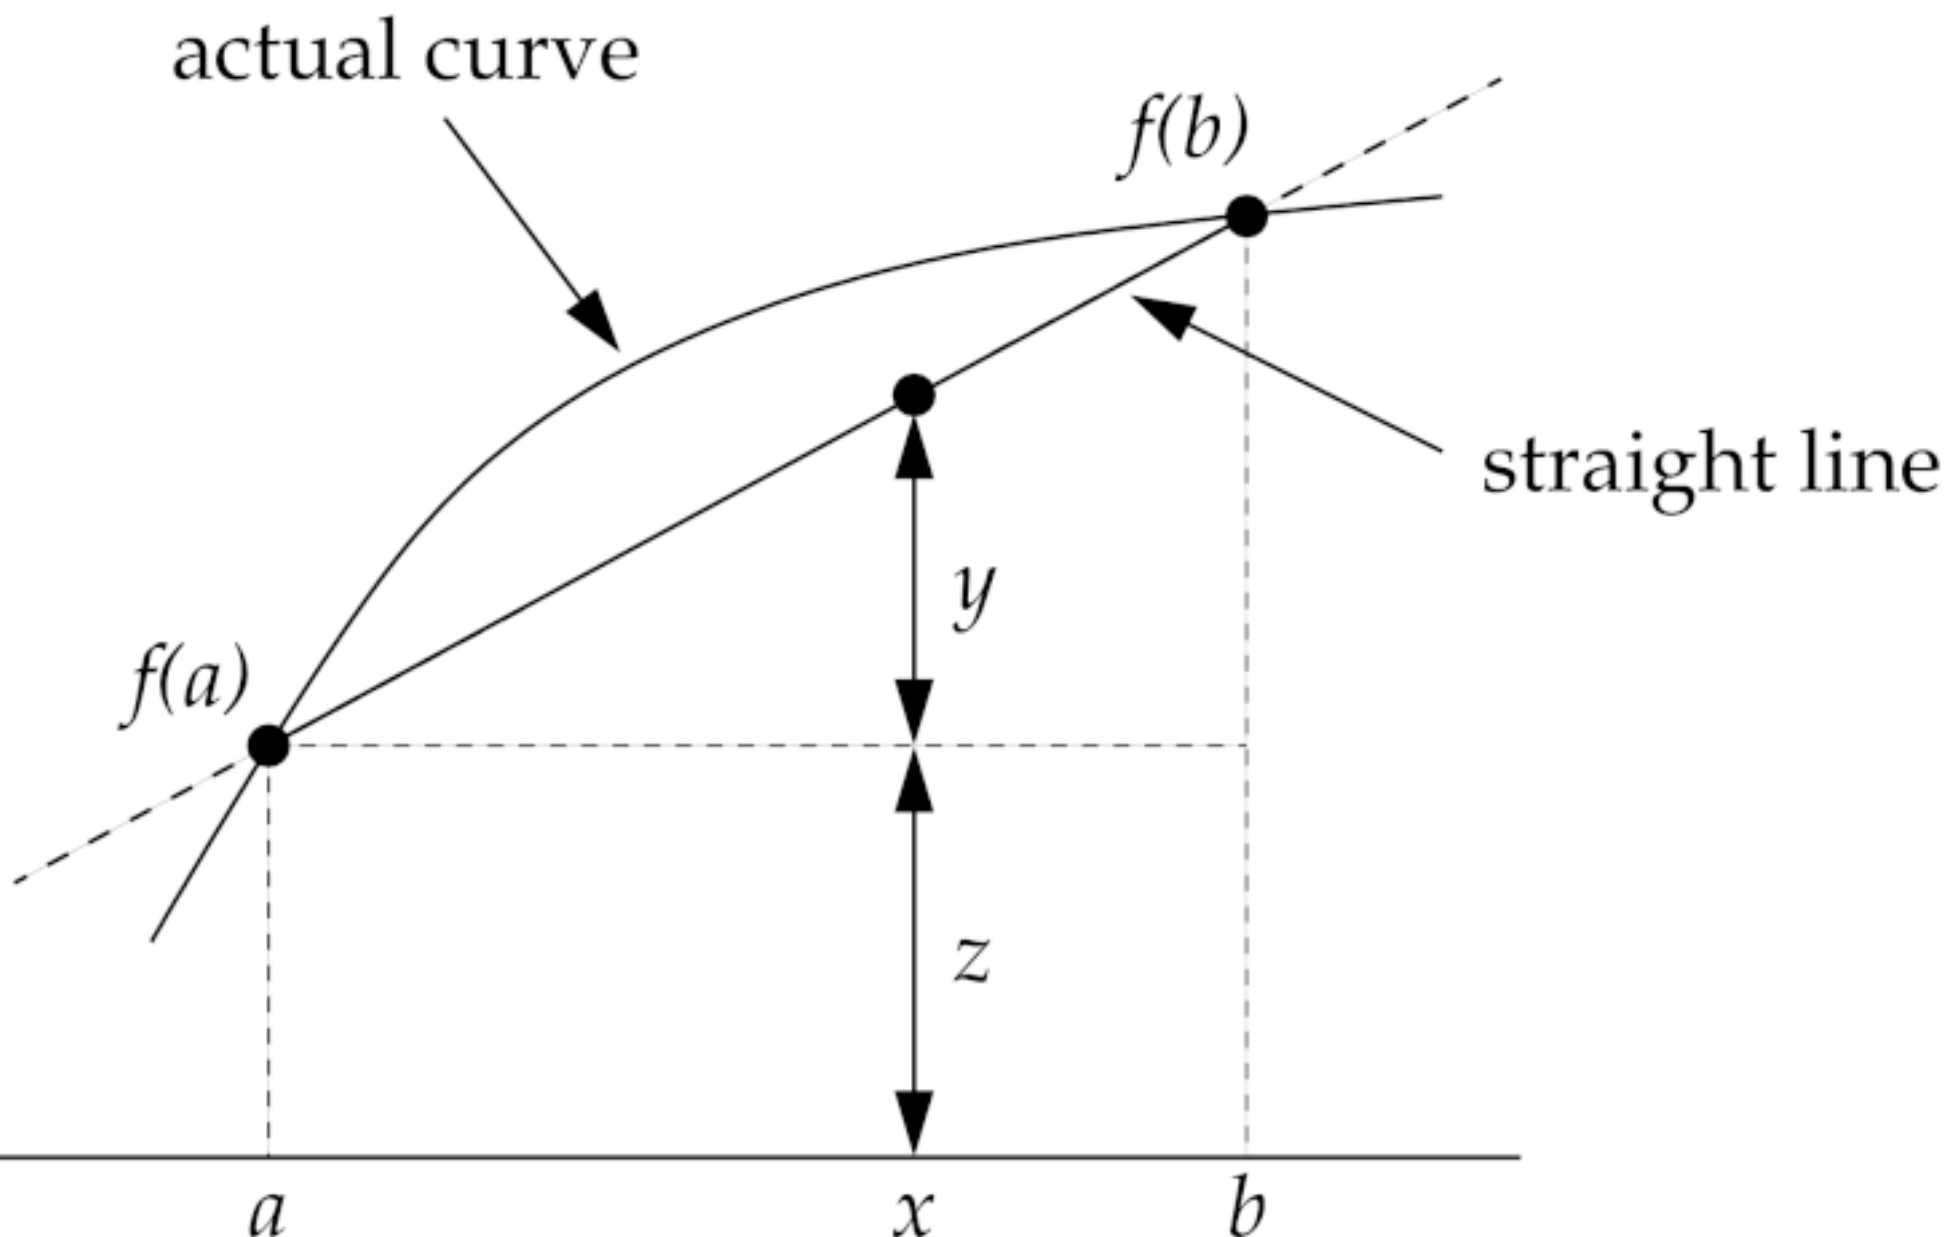

In [6]:
from IPython.display import Image,display
display(Image(filename="int_lin.png", width=600, height=600))

- Una vez asumida la forma funcional de la curva, esta puede ser usada fuera del intervalo $[a,b]$, es decir, puede ser extrapolada. 


- Por supuesto, cuanto más lejos uno se separa del intervalo más error tendrá asociado la extrapolación. 

### Error en la interpolación lineal

- Para analizar cuan bien estamos describiendo la curva tanto dentro como fuera del intervalo inicial, expandamos el valor de la función en $a$ y $b$ en serie Taylor.

    $$f(a)=f(x)+(x-a) f'(x)+\frac{1}{2}(x-a)^2 f''(x)+{\cal O}(x-a)^3,$$

    $$f(b)=f(x)+(x-b) f'(x)+\frac{1}{2}(x-b)^2 f''(x)+{\cal O}(x-b)^3.$$


- Introduciendo ambas expansiones en la formula de la interpolación lineal:

    $$f(x)=p(x)_l-\frac{1}{2}(x-a)(x-b)\,f''(x)+\cdots$$

    tomando $b-a=h$, el error esta por tanto acotado por

    $$\epsilon<\frac{h^2}{8}\vert f''(x)\vert.$$
    <br>

    que será el error de truncación asociado a nuestra aproximación lineal. 
    
    
- Si la derivada de la función es suave, nuestro error estará acotado por la mitad de la distancia entre dos puntos al cuadrado. 



- Para el error total también hay que tener en cuenta el error de redondeo, que en este caso, será relativamente poco importante, pues sólo involucra la suma de la función en dos puntos próximos.


- Si sólo hay dos puntos, no hay ninguna aproximación mejor si no se dispone de más información sobre $f(x)$.


- ¿Qué ocurre si tenemos más puntos?

In [ ]:
# Cota superior del error cometido crece cuadráticamente el ancho de la base --> Si cogemos base estrecha,
# el error cometido es pequeño --> todos los fenómenos físicos, a cantidades suficientemente cortas, son lineales

## 3.2.2: Interpolación polinómica de grado arbitrario

  * El polinomio de grado $N-1$ que nos permite interpolar una función $f$, que conocemos en $N$ puntos $x_i$ con $i=1,\cdots,N$, es el llamado interpolador de Lagrange, definido como:
 
     $$L(x,f)=\sum_{i=1}^N f(x_i)\,l_i(x),$$ 
     <br>
 
    donde las polinomios $l_i(x)$ deben cumplir la propiedad:     
 
 $$l_i(x_j)=\left\{\begin{array}{lr}1&\text{if}\quad j=i,\\0&\text{if}\quad j\neq i.\end{array}\right.$$
    <br>
    
    
  * Se puede demostrar que los únicos polinomios que cumplen esta propiedad son aquellos que forman la base de polinomios de Lagrange de grado $N-1$, definidos como 
 <br />
     
     $$l_i(x)=\prod_{\begin{array}{c}j=1\\[-4pt]j\neq i\end{array}}^N{\frac{x-x_j}{x_i-x_j}}=\frac{(x-x_1)}{(x_i-x_1)}\times\cdots\times \frac{(x-x_{i-1})}{(x_i-x_{i-1})}\times \frac{(x-x_{i+1})}{(x_i-x_{i+1})}\times\cdots\times \frac{(x-x_{N})}{(x_i-x_{N})}$$
 <br />
 
    
- De forma que L(x,f)

    $$L(x,f)=\sum_{i=1}^N f(x_i)\,l_i(x)=\sum_{i=1}^N f(x_i)\,\prod_{\begin{array}{c}j=1\\[-4pt]j\neq i\end{array}}^N{\frac{x-x_j}{x_i-x_j}},$$ 
 <br />
 
    es el único polinomio de orden $N-1$ que interpola (coincide con) la función $f$ en los puntos $x_i$ con $i=1,\cdots,N$. 
<br />

In [1]:
# Polinomio interpolador de Lagrange

import matplotlib.pyplot as plt
import numpy as np

# x_: eje X
# x: puntos seleccionados para interpolar
# coefs: representarn f(x_i)

def L(x_, x, coefs) -> np.array:
    N=x.size
    prod=np.ones_like(x_)
    s = np.zeros_like(x_)
    
    for i in range(N):
        for j in range(N):
            if i==j:
                continue
            prod*=(x_-x[j])/(x[i]-x[j])
        s+=coefs[i]*prod
        prod = np.ones_like(x_)
    return s

"""f = lambda x: np.sin(x)
x = np.linspace(-7,7,1000)
x_i = np.linspace(-5,5,2)
coefs = f(x_i)

pol = L(x, x_i, coefs)

plt.grid()
plt.plot(x, f(x), "b-")
plt.plot(x_i, f(x_i), "ro")
plt.plot(x, pol, "k--")
plt.show()"""

'f = lambda x: np.sin(x)\nx = np.linspace(-7,7,1000)\nx_i = np.linspace(-5,5,2)\ncoefs = f(x_i)\n\npol = L(x, x_i, coefs)\n\nplt.grid()\nplt.plot(x, f(x), "b-")\nplt.plot(x_i, f(x_i), "ro")\nplt.plot(x, pol, "k--")\nplt.show()'

### Ejercicio 3.1: demostración de la interpolación de Lagrange

Demostrar la existencia y unicidad del interpolador de Lagrange.

In [ ]:
# Cuanto mayor sea el orden del polinomio, más fallará en los extremos pero mejor se ajustará en los
# puntos entre los extremos. Solución: splines

### Implementación numérica de la interpolación polinómica

- El problema reside en que obtener L(x,f) requiere realizar ${\cal O}(N^2)$ operaciones. 


- Los problemas ${\cal O}(N^2)$ suelen ser extremadamente lentos e ineficaces. 


- Sin embargo, el problema de la interpolación puede convertirse en un problema ${\cal O}(N)$. Es lo que vamos a ver a continuación:



- Definiendo el polinomio:

    $$\omega(x)=\prod_{i=1}^N (x-x_i),$$

    la base de polinomios de Lagrange puede escribirse como:

    $$l_i(x)=\frac{\omega(x)}{x-x_i}\frac{1}{\prod_{\begin{array}{c}j=1\\[-4pt] j\neq i\end{array}}^N (x_i-x_j)}=\omega(x)\frac{u_i}{x-x_i},$$

    donde 

    $$u_i=\prod_{\begin{array}{c}j=1\\[-4pt] j\neq i\end{array}}^N \frac{1}{(x_i-x_j)}$$

    son los llamados pesos bariocéntricos, que al ser independientes de x, pueden calcularse sólo una vez.


- De esta forma, el interpolador de Lagrange puede escribirse como

    $$L(x,f)=\omega(x)\sum_{i=1}^N f(x_i)\,\frac{u_i}{x-x_i},$$ 

    que aún involucra ${\cal O}(N^2)$ operaciones. Sin embargo, interpolando f(x)=1, se obtiene:

    $$L(x,1)=\omega(x)\sum_{i=1}^N \,\frac{u_i}{x-x_i},$$ 

    y por tanto:

    $$L(x,f)=\frac{L(x,f)}{L(x,1)}=\frac{\displaystyle\sum_{i=1}^N f(x_i)\,\frac{u_i}{x-x_i}}{\displaystyle\sum_{i=1}^N \,\frac{u_i}{x-x_i}},$$

    que permite obtener la función de interpolación con sólo $N$ operaciones.
    
    

- La cuestión central es que, dados $N+1$ puntos experimentales $x_i$, podemos calcular una sóla vez los $N+1$ pesos bariocéntricos $u_i$, que luego podrán usarse para cualquier valor de x en el que queramos calcular nuestra función interpolada.  
    
    
- De esta forma, para calcular la función de interpolación $L(x,f)$ en cualquier punto $x$, sólo tendremos que realizar $N$ operaciones, o un sólo bucle for.   

inf


/tmp/ipykernel_7462/2422665832.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  ui = 1/np.prod(XI*XJ)


### El fenómeno de Runge

- Uno puede pensar que al aumentar el grado del polinomio la precisión de la interpolación aumenta. 


- Sin embargo, no es el caso: un polinomio de grado alto involucra grandes fluctuaciones que se amplifican en los extremos del intervalo.


- La mejor forma de verlo es mediante un ejemplo.  

### Ejemplo 3.1: la función de Runge

1. Estudiar la interpolación polinómica de la función de Runge:

    $$f(x)=\frac{1}{1+25 x^2}$$

   en el intervalo [-1,1] usando polinomios de grado $N=10,\cdots,15.$


2. Estudiar la extrapolación polinómica de la función de Runge en el intervalo [-1.5,1.5].

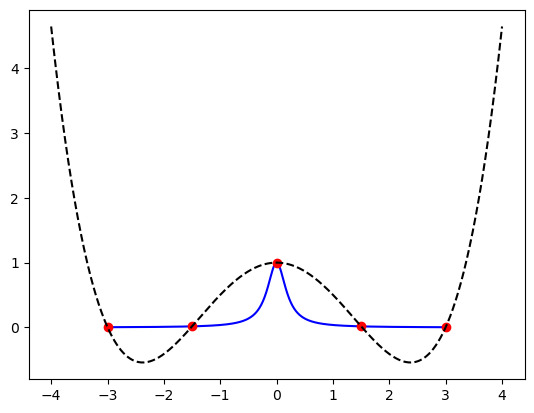

In [6]:
f = lambda x: 1/(1+25*x**2)
x = np.linspace(-3,3,1000)
x_i = np.linspace(-3,3,5)
coefs = f(x_i)
x_ = np.linspace(-4,4,1000)

plt.plot(x, f(x), "b-")
plt.plot(x_i, coefs, "ro")
plt.plot(x_, L(x_, x_i, coefs), "k--")
plt.show()

# 3.3 Interpolación a trozos: splines

- La interpolación polinómica funciona bien para intervalos pequeños y polinomios de grado bajo. 


- Sin embargo no funciona bien para intervalos grandes (para un gran número de puntos) y un grado alto.


- Los splines hacen uso de este hecho:
<br>

    1. Para cada uno de los sub intervalos definidos por cada 2 puntos sucesivos en los que conocemos la función.
    2. Usamos un polinomio de grado bajo para interpolar esos dos puntos. 
<br>    

    
- Es decir, representan un ajuste de la curva inicial "a trozos" (piecewise) por medio de polinomios.    


- El caso más sencillo es un spline lineal:

    $$f(x)\simeq s_i(x)\quad \text{siendo}\quad s_i(x)=f(x_i)+\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}(x-x_i)\quad\text{con}\quad x_i\le x< x_{i+1}.$$
<br>

- Sin embargo, el caso más habitual (y el que en general funciona mejor) es el spline cúbico:

$$f(x)\simeq s_i(x)\quad \text{siendo}\quad s_i(x)=\sum_{j=0}^3{a_{ij}\,(x-x_i)^j}\quad\text{con}\quad x_i\le x< x_{i+1},\; i\in \{1,2,\cdots , N\}$$


- Si conocemos la función en $N+1$ puntos, $x_1,x_2,\cdots, x_{N+1}$, necesitamos construir un polinomio de orden 3 en $N$ intervalos.


- Por tanto, necesitamos fijar $4N$ grados de libertad.

    1. Conocemos la función en $N+1$ puntos.   
    
    2. Los diferentes polinomios deben ser continuos, y tener una primera y segunda derivada continua en los puntos intermedios. Es decir:
    
       \begin{align}
            s_i(x_{i+1})=&s_{i+1}(x_{i+1}),\quad\forall i\in \{1,N-1\},\nonumber\\
            s'_i(x_{i+1})=&s'_{i+1}(x_{i+1}),\quad\forall i\in \{1,N-1\},\nonumber\\
            s''_i(x_{i+1})=&s''_{i+1}(x_{i+1}),\quad\forall i\in \{1,N-1\},\nonumber\\
       \end{align}
    
       que implican $N+1+3(N-1)=4N-2$ condiciones.   
       <br>
    
    3. Faltan dos grados de libertar por determinar para resolver de forma unívoca nuestro problema. Se suelen fijar imponiendo condiciones de contorno (condiciones para el punto inicial y final):
    <br>    
    <br>

       - Condiciones naturales: $\,\;s''_1(x_1)=s''_{n-1}(x_n)=0$.
       <br>
       
       - Condiciones periódicas: $\,s'_1(x_1)=s'_{n-1}(x_n)$ y $s''_1(x_1)=s''_{n-1}(x_n)$.
       <br>
       
       - Valores de frontera:     $\;\;\quad s'_1(x_1)=r_1$, y  $s'_{n-1}(x_n)=r_2$.       
      

## 3.3.1 Algoritmo para determinar los coeficientes de un spline cúbico

- La segunda derivada del spline es una función lineal:

    $$s''_i(x)=2\,a_{i2}+6\,a_{i3}\,(x-x_i),$$
    
    por tanto, teniendo en cuenta que  $s''_i(x_i)=2\,a_{i2}$, podemos escribir:

$$s''_i(x)=s''_i(x_i)+6\,a_{i3}\,(x-x_i),$$


- Por otro lado, la ecuación de continuidad para la segunda derivada implica:

    $$ s''_i(x_{i+1})=s_i''(x_i)+6\,a_{i3}\,(x_{i+1}-x_{i})=s_{i+1}''(x_{i+1}),\quad\Rightarrow\quad 6\,a_{i3}=\frac{s_{i+1}''(x_{i+1})-s_{i}''(x_{i})}{x_{i+1}-x_i},$$

    y por tanto:

\begin{align}
s''_i(x)\,=&\,s''_i(x_i)+\frac{s_{i+1}''(x_{i+1})-s_{i}''(x_{i})}{x_{i+1}-x_i}\,(x-x_i)\nonumber\\
        =&\,s''_{i+1}(x_{i+1})\,\frac{x-x_i}{x_{i+1}-x_i}+s''_i(x_i)\,\frac{x_{i+1}-x}{x_{i+1}-x_i}.
\end{align}


* Si hacemos la integral indefinida de $s''_i(x)$ con respecto a x obtenemos:

\begin{align}
s'_i(x)\,=&\,s''_{i+1}(x_{i+1})\,\frac{\left(x-x_i\right)^2}{2\left(x_{i+1}-x_i\right)}-s''_i(x_i)\,\frac{\left(x_{i+1}-x\right)^2}{2\left(x_{i+1}-x_i\right)}+\alpha_i,\nonumber\\
s_i(x)\,=&\,s''_{i+1}(x_{i+1})\,\frac{\left(x-x_i\right)^3}{6\left(x_{i+1}-x_i\right)}+s''_i(x_i)\,\frac{\left(x_{i+1}-x\right)^3}{6\left(x_{i+1}-x_i\right)}+\alpha_i \left(x-x_i\right)+\beta_i.\nonumber\\
\end{align}


* Sin embargo, teniendo en cuenta las condiciones de la interpolación, $s_i(x_i)=f(x_i)$ y $s_i(x_{i+1})=f(x_{i+1})$ tenemos que

    \begin{align}
    s_i(x_i)=&\,\frac{1}{6}s''_i(x_i)\,\left(x_{i+1}-x\right)^2+\beta_i=f(x_i)\nonumber\\
        s_i(x_{i+1})=&\,\frac{1}{6}s''_{i+1}(x_{i+1})\,\left(x_{i+1}-x\right)^2+\alpha_i\,\left(x_{i+1}-x_i\right)+\beta_i=f(x_{i+1}),\nonumber
    \end{align}

    y por tanto, despejando, tenemos:

    \begin{align}
    \beta_i\,=&\,f(x_i)-\frac{1}{6}s''_i(x_i)\,\left(x_{i+1}-x\right)^2,\nonumber\\
    \alpha_i\,=&\,\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}-\frac{x_{i+1}-x_i}{6}\left(s''_{i+1}(x_{i+1})-s''_i(x_i)\right).
    \end{align}


- Comparando con la definición inicial de nuestro spline:

    $$s_i(x)=\sum_{j=0}^3{a_{ij}\,(x-x_i)^j},$$

    obtenemos por tanto que:

\begin{align}
a_{i0}\,=&\,f(x_i),\nonumber\\
a_{i1}\,=&\,\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}-\frac{x_{i+1}-x_i}{6}\left(s''_{i+1}(x_{i+1})+2s''_i(x_i)\right),\nonumber\\
a_{i2}\,=&\,\frac{s''_i(x_i)}{2},\\
a_{i3}\,=&\,\frac{s''_{i+1}(x_{i+1})-s''_i(x_i)}{6\left(x_{i+1}-x_i\right)}.
\end{align}
<br>


- Sólo nos queda determinar el valor de las segundas derivadas de los splines $s''_{i}(x_i)$.  
  Cosa que podemos hacer explotando la única condición de continuidad que nos queda por usar: $s_{i-1}'(x_i)=s_i'(x_i)$.
    <br>
    
    \begin{align}
    s'_{i-1}(x_i)=&\frac{1}{2}s''_i(x_i)\left(x_{i}-x_{i-1}\right)+\frac{f(x_i)-f(x_{i-1})}{x_i-x_{i-1}}-\frac{x_i-x_{i-1}}{6}\left(s''_{i}(x_i)-s''_{i-1}(x_{i-1}) \right)\nonumber\\
                 =&-\frac{1}{2}s''_i(x_i)\left(x_{i+1}-x_{i}\right)+\frac{f(x_{i+1})-f(x_{i})}{x_{i+1}-x_{i}}-\frac{x_{i+1}-x_{i}}{6}\left(s''_{i+1}(x_{i+1})-s''_{i}(x_{i})\right)=s'_i(x_i),\nonumber
    \end{align}
  
    que nos permite encontrar la relación:

    $$\frac{1}{6}s''_{i-1}(x_{i-1})\,(x_{i}-x_{i-1})+\frac{1}{3}s''_{i}(x_{i})\,(x_{i+1}-x_{i-1})+\frac{1}{6}s''_{i+1}(x_{i+1})\,(x_{i+1}-x_{i})=\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}-\frac{f(x_{i})-f(x_{i-1})}{x_{i}-x_{i-1}},$$

    que proporciona un sistema lineal de ecuaciones para obtener $s_i''(x_i)$.


- Llamando:

    \begin{align}
    \mu_i=&\frac{x_{i+1}-x_{i}}{x_{i+1}-x_{i-1}},\nonumber\\
    \nu_i=&\frac{x_{i}-x_{i-1}}{x_{i+1}-x_{i-1}},\nonumber\\
    \lambda_i=&\frac{6}{x_{i+1}-x_{i-1}}\left(\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}-\frac{f(x_{i})-f(x_{i-1})}{x_{i}-x_{i-1}}\right),
    \end{align}

    el sistema de ecuaciones se simplifica a

$$\nu_i\,s''_{i-1}(x_{i-1}) + 2\,s''_{i}(x_{i})+\mu_i\,s''_{i+1}(x_{i+1})=\lambda_i,\quad\text{con}\quad i=1,\cdots,n-1$$

- Aplicando condiciones de contorno naturales uno encuentra que:

    $$\mu_0=0,\quad\nu_n=0,\quad\lambda_0=\lambda_n=0,$$

    que implica escribir el sistema de ecuaciones

    \begin{equation} 
    \left(\begin{array}{ccccc}
    2    & 0    &       &         &         &    \\
    \nu_1&  2   &\mu_1  &         &         &    \\
     & \nu_2&  2    &\mu_2    &         &    \\
     &      & \ddots&\ddots   &\ddots   &    \\
     &      &       &\nu_{n-1}&2        &\mu_{n-1}\\
     &      &       &         & 0       & 2     
     \end{array}    
    \right)\left(
    \begin{array}{c}
    0\\
    s_1''(x_1)\\
    s_2''(x_2)\\
    \vdots\\
    s_{n-1}''(x_{n-1})\\
    0\\
    \end{array}
    \right)=
    \left(
    \begin{array}{c}
    0\\
    \lambda_1\\
    \lambda_2\\
    \vdots\\
    \lambda_{n-1}\\
    0\\
    \end{array}
    \right)
    \end{equation}

    que aprenderemos a resolver en  tema 5.  

### Ejemplo 3.2: interpolación por splines de la función de Runge

Estudiar la interpolación por medio de splines cúbicos de la función de Runge:

$$f(x)=\frac{1}{1+25 x^2}$$

en el intervalo [-1,1] usando $N=10,\cdots,15$ intervalos ($N+1$  puntos). 

**Ayuda:** para resolver el sistema de ecuaciones para las derivadas segundas tener en cuenta que el módulo linalg del paquete numpy incluye la función inv, que calcula la inversa de una matriz.

## Ejercicio 3.2: la interacción protón - neutrón

Las primeras medidas de la sección eficaz $\sigma(E)$ de la dispersión protón-neutrón fueron tomadas por Rutherford a principios del S XX.  
Los valores obtenidos fueron:

|i    |   1 |   2 |   3 |  4  |  5  |  6  |  7  |  8  |  9  |
| :---:  |:---:  | :---:  | :---:  | :---:  | :---:  | :---:  | :---:  | :---:  | :---:  |   
|$E_i$ (MeV) | 0 |25| 50| 75| 100| 125| 150| 175| 200|
|$\sigma(E_i)$ (mb)  |10.6 | 16.0 |45.0| 83.5| 52.8| 19.91| 10.8 |8.25 |4.71|
|Error (mb) |9.34| 17.9| 41.5| 85.5| 51.5| 21.5| 10.8| 6.29| 4.14|



1. Representar estos datos como función de la energía. 


2. Usar un polinomio de grado 3 para interpolarlos. 


3. Comparar con el mayor interpolador que uno puede usar con ese número de datos. 


4. Comparar con el resultado obtenido al usar splines cúbicos. 

In [ ]:
# Interpolación con splines lineales en numpy:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0,2*np.pi, 10) # Cuantos más puntos cojas, más cerca estarán y más suave te quedará la curva
y=np.sin(x)

xvals = np.linspace(0,2*np.pi, 200) # Es como ajuste fino
yinterp = np.interp(xvals, x, y)
#plt.plot(x, y, "ro")
plt.plot(xvals, yinterp, "-x")
plt.show()

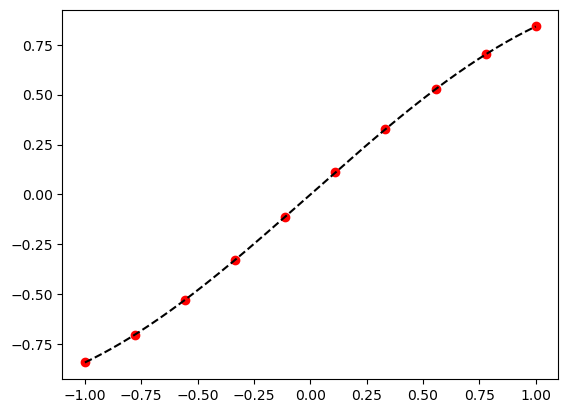

In [1]:
# Interpolación por splines cúbicos con scipy
from scipy import interpolate
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x_pts = np.linspace(-1,1,10)
    y_pts = np.sin(x_pts)

    tck = interpolate.splrep(x_pts, y_pts)
    return interpolate.splev(x, tck)

x_pts = np.linspace(-1,1,10)
y_pts = np.sin(x_pts)
x = np.linspace(-1, 1, 1000)
y = f(x)

plt.plot(x_pts, y_pts, "ro")
plt.plot(x, y, "k--")

plt.show()

# 3.4:  Aproximaciones racionales: aproximantes de Padé 

- Las aproximaciones racionales permite describir correctamente funciones con polos o singularidades. 


- También son mucho más estables que los polinomios de grados altos.


- En particular, un aproximantes de Padé de orden $[M/N]$ de una función $f(x)$ se definen como:

    $$P_{M/N}(x)=\frac{R_M(x)}{Q_N(x)}=\frac{\sum_{i=0}^M r_i\, x^i}{\sum_{i=0}^N q_i\, x^i},$$

    donde el valor de los coeficientes $r_i$, $q_i$ están constreñidos para satisfacer la serie de Taylor de $f(x)$ a ${\cal O}(x^{N+M+1})$, es decir, la aproximación de Padé $P_{M/N}$ de una función $f(x)$ satisface: 
    
    $$P_{M/N}(x)=a_0+a_1 x+\cdots+{\cal O}(x^{M+N+1}),$$
    
   donde los coeficientes $a_n=\left.d^{n}f(x)/d x^n\right.\vert_{x=0}$ son los correspondientes a la serie de Taylor de $f(x)$ en $x=0$. 
   
   
- Está relación implica por tanto que:

$$\left.\frac{\text{d}^n f(x)}{\text{d} x^n}\right\vert_{x=0} = \left.\frac{\text{d}^n P_{M/N}(x)}{\text{d} x^n}\right\vert_{x=0},\quad\text{con}\quad n =0,\cdots N+M.$$

- Multiplicando $Q_N(x)\times P_{N/M}$ estas ligaduras implican que:

    \begin{align}
    r_0 = &q_0\,a_0,\nonumber\\
    r_1 =& q_0\,a_1+q_1\,a_0\nonumber\\
    \vdots\quad& \qquad\quad \vdots\nonumber\\
    r_i =& \sum_{k=0}^i q_{k}\,a_{i-k}\nonumber\\
    \vdots\quad& \qquad\quad \vdots\nonumber\\
    r_M =& \sum_{k=0}^M q_{k}\,a_{M-k}\nonumber\\
    0 =& \sum_{k=0}^{N} q_{k}\,a_{M+1-k}\nonumber\\
    \vdots\quad& \qquad\quad \vdots\nonumber\\
    0 =& \sum_{k=0}^{N} q_{k}\,a_{M+N-k}\nonumber\\
    \end{align}

    donde 

$$q_j=0,\;\;\forall\;j>N\quad\text{y}\quad a_k=0,\;\;\forall\;k<0.$$

## Ejemplo 3.3: interpolando singularidades

Usar el aproximante de Padé $[3/3]$ de la $\tan(x)$ en el intervalo $[0,\pi]$.

## Ejercicio 3.3: aproximantes P[N/1]

Demostrar que en el caso de aproximar una función f(x) con una secuencia de Padé P[N/1] se satisface la igualdad

$$P_{N/1}(x)=\frac{R_N(x)}{q_0+q_1 x}=\sum_{i=0}^{N-1} a_i\, x^i+\frac{a_N\,x^N}{1-\frac{a_{N+1}}{a_N}\,x},$$

donde los coeficientes $a_n$ vienen dados por  

$$a_n=\frac{1}{n!}f^{(n)}(x).$$

## Ejercicio 3.4: aproximantes de Padé y resonancias.

Una resonancia es una partícula inestable, es decir, que se desintegra un tiempo después de haberse producido. 

De forma rigurosa una resonancia se puede definir como un polo que aparece en una amplitud de dispersión en una hoja de Riemann no física. 

El mesón $\rho(770)$ es la resonancia vectorial (con momento angular uno) mesónica (formada por un quark y un antiquark) más ligera que existe. Se genera cuando dos piones interaccionan con momento angular uno. 
Esta interacción, definida por la función compleja $t_1^1(s)$, se puede describir de forma fenomenológica por medio de la parametrización:

\begin{eqnarray}
&&t_1^{1}(s+i\epsilon)=\frac{\sqrt{s}}{2 k}\frac{1}{\cot\delta_1(s)\mp i},\quad k=\sqrt{\frac{s}{4}-M_\pi^2},\\
&&\cot\delta_1(s)=\frac{s^{1/2} }{2k^3}(M_\rho^2-s)\left\{
\frac{2M_\pi^3}{M_\rho^2\sqrt{s}}+B_0+B_1 w(s)\right\},
\nonumber\\
&&w(s)=\frac{\sqrt{s}-\sqrt{s_0-s}}{\sqrt{s}+\sqrt{s_0-s}},\quad
s_0^{1/2}=1.05\,\text{GeV},
  \label{eq:Plowparam}   
\end{eqnarray}


donde $\epsilon>0$, $M_\rho=0.7736\,\text{GeV}$, $M_\pi=139.57\,\text{MeV}$, $B_0=1.043$ y $B_1=0.19$.


1. Representar la parte real e imaginaria de la función $t_1^1(s)$ para $4M_\pi^2\lt s\le 1\,\text{GeV}^2$.
   La parte imaginaria debería tener un máximo entorno a $\sqrt s\sim0.77$ GeV, mientras que la parte real debería generar un cambio de signo. 


2. Comprobar que la función tiene un corte en el eje real en ese intervalo, es decir, que $t_1^1(s+i\epsilon)\neq  t_1^1(s-i\epsilon)$ para $\epsilon >0$.


3. Aproximar la función $t_1^1(s)$ con una secuencia de Pades $P_{N/1}$ con $2\le N\le 4$.


4. Esas secuencias de Padé nos permiten continuar analíticamente nuestra función $t_1^1(s)$ a través de su corte, y por tanto acceder por debajo del corte a lo que llamamos la segunda hoja de Riemann. Explicar que las secuencias de Padé $P_{N/1}$ contienen un polo, y obtener su valor en $\sqrt s$. Comparar con su valor exacto:

$$\sqrt s_\rho= 764-i\,73\,\text{MeV}.$$

**Final del Tema 3**